In [1]:
import sys
sys.path.append("/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/")
from skew_correction import full_correction

import numpy as np
import os 
import sys
import astropy.units as u
import astropy.constants as const
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from concurrent.futures import ProcessPoolExecutor
import concurrent
import concurrent.futures
from astropy.visualization import ImageNormalize, AsinhStretch
from juanfit import gaussian
from plotting_modules import doppler_plot, amplitude_plot
from skew_parameter_search import detrend_dopp
from fancy_colorbar import plot_colorbar

from matplotlib.animation import FuncAnimation
from astropy.visualization import (ImageNormalize, AsinhStretch,
                                   ) 
from IPython.display import HTML, display

In [3]:
spice_file = "~/work/spice_psf/spice_data/solo_L2_spice-n-ras_20241023T091006_V02_285212965-003.fits"

with fits.open(spice_file) as hdul:
    hdul.info()
    spice_NeVIII_data = hdul[2].data[0].copy()
    spice_NeVIII_header = hdul[2].header.copy()
    spice_CIII_data = hdul[5].data[0].copy()
    spice_CIII_header = hdul[5].header.copy()
spice_NeVIII_data = spice_NeVIII_data.T
spice_CIII_data = spice_CIII_data.T
# spice_NeVIII_header["NAXIS1"] = 60
# spice_NeVIII_header["NAXIS2"] = 240
# spice_NeVIII_data = spice_NeVIII_data[30:90,240:480,:]

Filename: /cluster/home/zhuyin/work/spice_psf/spice_data/solo_L2_spice-n-ras_20241023T091006_V02_285212965-003.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  O II 718 - Peak    1 PrimaryHDU     410   (128, 834, 50, 1)   float32   
  1  N IV 765 - Peak    1 ImageHDU       410   (128, 834, 25, 1)   float32   
  2  Ne VIII 770 - Peak    1 ImageHDU       411   (128, 834, 50, 1)   float32   
  3  S V 786 / O IV 787 (Merged)    1 ImageHDU       420   (128, 834, 58, 1)   float32   
  4  Ly Gamma 972 - Peak    1 ImageHDU       410   (128, 834, 17, 1)   float32   
  5  C III 977 - Peak    1 ImageHDU       413   (128, 834, 36, 1)   float32   
  6  O VI 1032 - Peak    1 ImageHDU       413   (128, 834, 34, 1)   float32   
  7  N III 991 (Merged)    1 ImageHDU       418   (128, 834, 56, 1)   float32   
  8  VARIABLE_KEYWORDS    1 BinTableHDU    411   1R x 29C   [128D, 128I, 128I, 128I, 128I, 128I, 128E, 128E, 128E, 128E, 4I, 4I, 4I, 4I, 4J, 4J, 4J, 4J, 2944A, 128D, 128D, 50

In [4]:
spice_NeVIII_data.shape, spice_CIII_data.shape

((128, 834, 50), (128, 834, 36))

In [ ]:
NeVIII_wvl = spice_NeVIII_header["CRVAL3"] + \
spice_NeVIII_header["CDELT3"] * (np.arange(1, spice_NeVIII_header["NAXIS3"]+1) - spice_NeVIII_header["CRPIX3"])
NeVIII_wvl = NeVIII_wvl*10

In [5]:
CIII_wvl = spice_CIII_header["CRVAL3"] + \
spice_CIII_header["CDELT3"] * (np.arange(1, spice_CIII_header["NAXIS3"]+1) - spice_CIII_header["CRPIX3"])
CIII_wvl = CIII_wvl*10

In [6]:
load_data = False

In [7]:
if not load_data:
    raw_results_CIII = full_correction(spice_CIII_data, spice_CIII_header, 0, 0, nthreads=12, linelist={'C III 977':977.0})
else:
    with np.load("/cluster/home/zhuyin/work/spice_psf/spice_skew_20231026/raw_CIII_results_20231026T093152.npz", allow_pickle=True) as f:
        raw_results_CIII = dict(f)

/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:92: RuntimeWarning: All-NaN slice encountered
  spice_dat = copy.deepcopy(spice_dat_in) - np.nanmean(np.nanmin(spice_dat_in,axis=0))
/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:94: RuntimeWarning: Mean of empty slice
  signal = np.nanmean(signal_cube,axis=(0,2))


In [12]:
if not load_data:
    raw_results_NeVIII = full_correction(spice_NeVIII_data, spice_NeVIII_header, 0, 0, nthreads=12, linelist={'Ne VIII 770':770.4})
else:
    with np.load("/cluster/home/zhuyin/work/spice_psf/spice_skew_20231026/raw_NeVIII_results_20231026T093152.npz", allow_pickle=True) as f:
        raw_results_NeVIII = dict(f)

In [8]:
def correction_preview(best_correction_results, load_data=load_data):
    if load_data:
        plt_linefits = best_correction_results['linefits'].item()
    else:
        plt_linefits = best_correction_results['linefits']
    ymin,ymax = best_correction_results['ymin'],best_correction_results['ymax']
    line_name = list(plt_linefits[0].keys())[0]
    date = plt_linefits[0][0]['amplitudes'].meta['DATE-OBS']

    fig=plt.figure(figsize=[16,8])
    gs = fig.add_gridspec(nrows=2,ncols=2,width_ratios=[1,1],height_ratios=[7,1])
    cbaxes = [fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1])]
    axes = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1])]

    plt.suptitle('Corrected fits for '+line_name+' at '+date)
    amplitude_plot(plt_linefits[0][0],axis=axes[0], cbaxis=cbaxes[0], ymin=ymin, ymax=ymax)
    doppler_plot(plt_linefits[0][0],axis=axes[1], cbaxis=cbaxes[1], doppmin=-0.075, doppmax=0.075, ymin=ymin,ymax=ymax)
    axes[1].set(title='Doppler; best xshift, yshift='+str(best_correction_results['xlshift'])+','+str(best_correction_results['ylshift']))

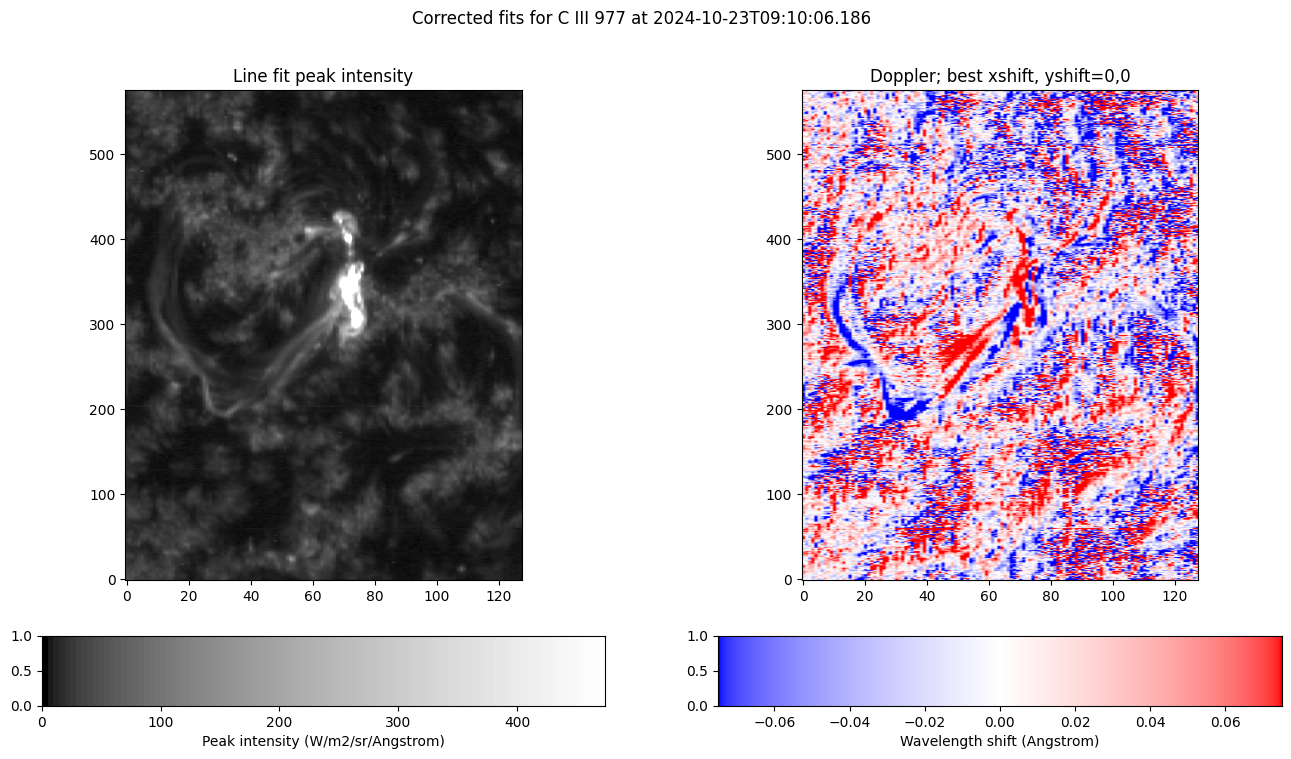

In [9]:
correction_preview(raw_results_CIII)

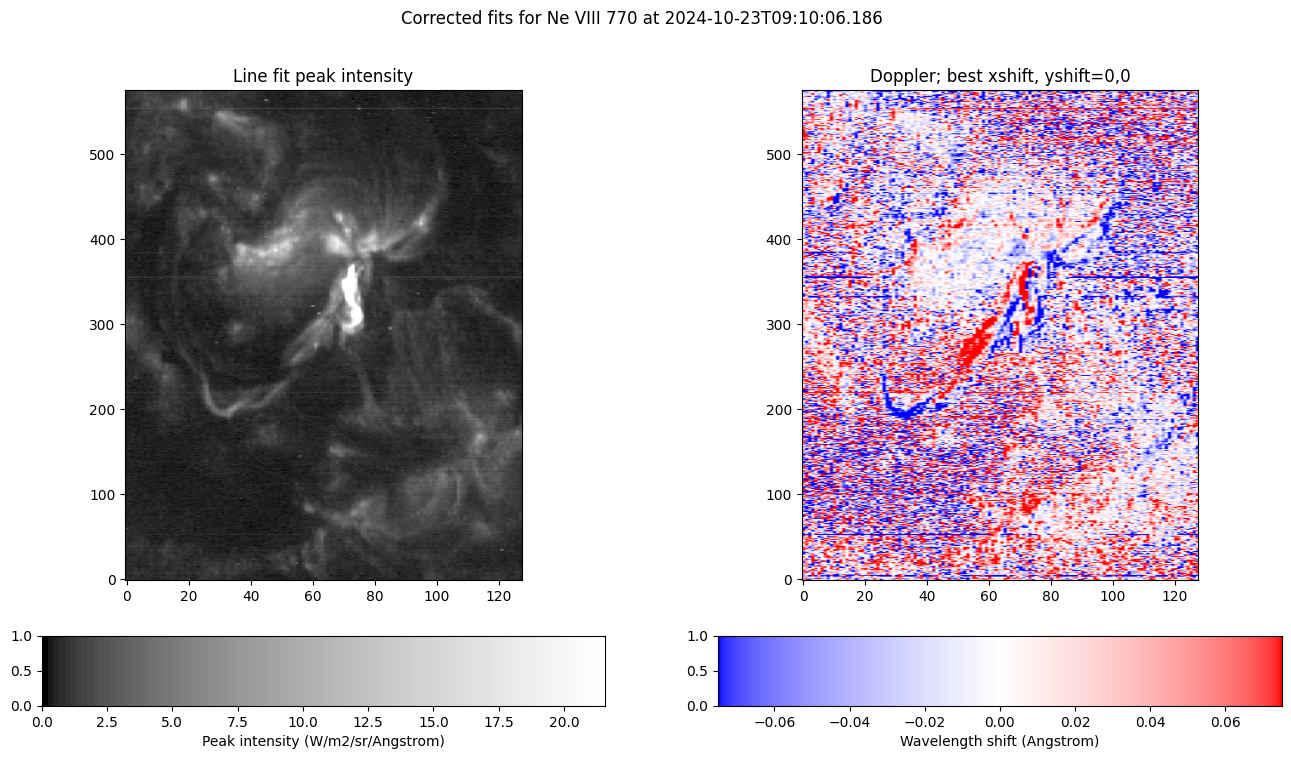

In [13]:
correction_preview(raw_results_NeVIII)

In [10]:
best_skew_x_CIII, best_skew_y_CIII = 3.3333, -1.6667

if not load_data:
    best_correction_results_CIII = full_correction(spice_CIII_data, spice_CIII_header, best_skew_x_CIII, best_skew_y_CIII, nthreads=12,
                                               linelist={'C III 977':977.0})
else:
    with np.load("/cluster/home/zhuyin/work/spice_psf/spice_skew_20231026/best_CIII_results_20231026T093152.npz", allow_pickle=True) as f:
        best_correction_results_CIII = dict(f)

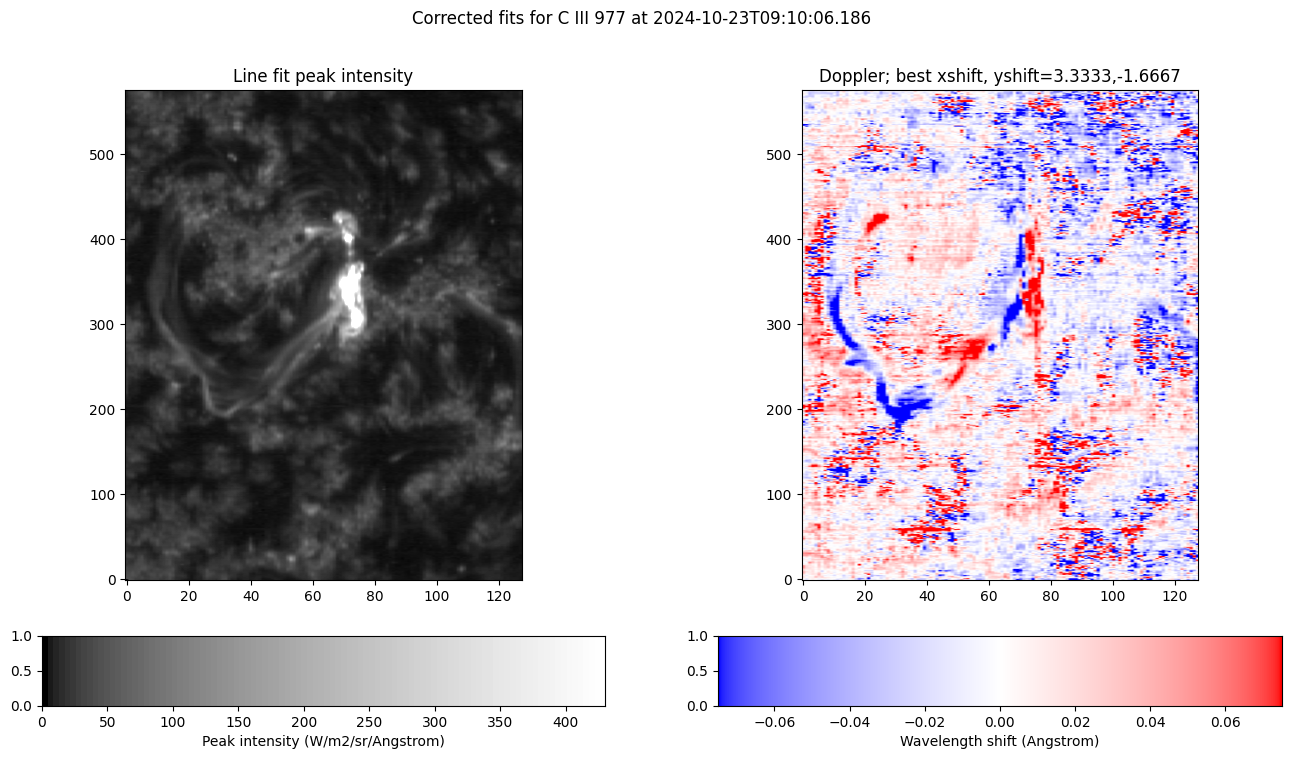

In [11]:
correction_preview(best_correction_results_CIII)

In [19]:
best_skew_x_NeVIII, best_skew_y_NeVIII = 2.7, -2.3

if not load_data:
    best_correction_results_NeVIII = full_correction(spice_NeVIII_data, spice_NeVIII_header, best_skew_x_NeVIII, best_skew_y_NeVIII, nthreads=12,
                                                linelist={'Ne VIII 770':770.4})
else:
    with np.load("/cluster/home/zhuyin/work/spice_psf/spice_skew_20231026/best_NeVIII_results_20231026T093152.npz", allow_pickle=True) as f:
        best_correction_results_NeVIII = dict(f)

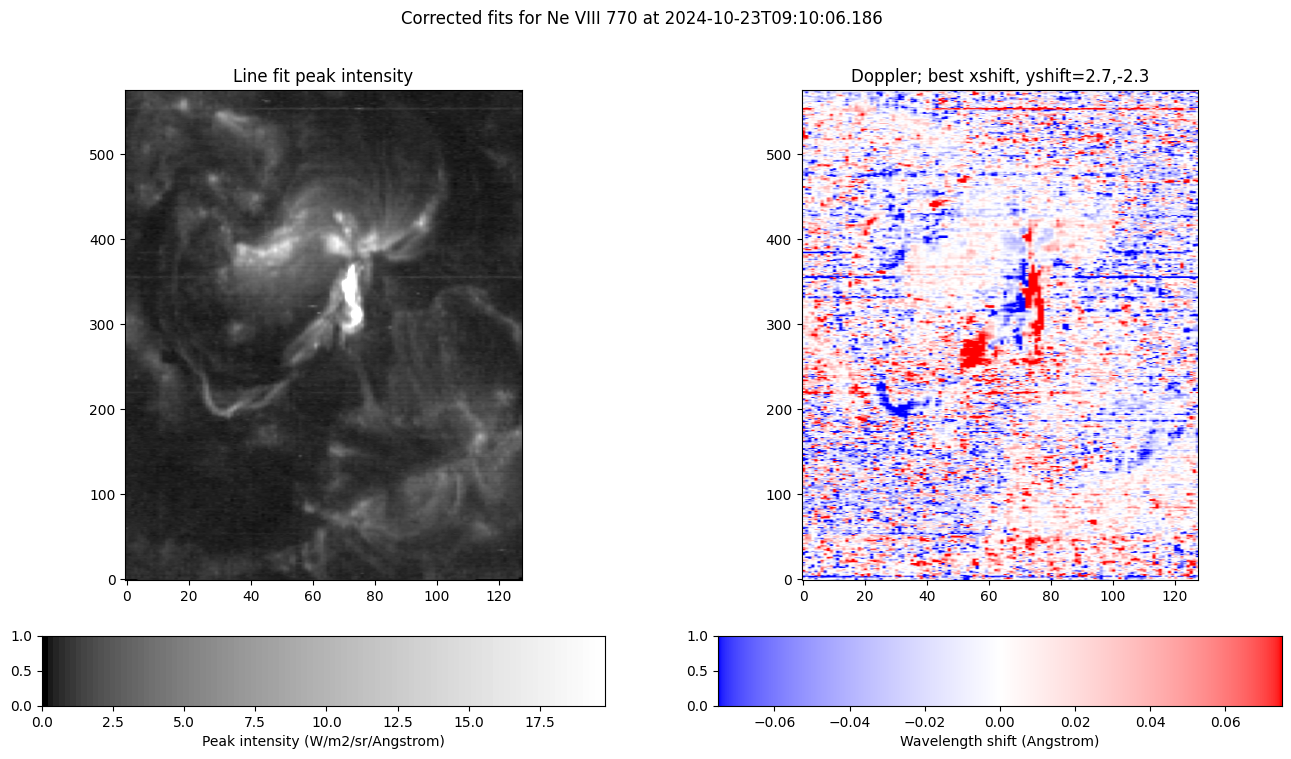

In [20]:
correction_preview(best_correction_results_NeVIII)

In [21]:
if not load_data:
    np.savez("/cluster/home/zhuyin/work/spice_psf/spice_skew_20231026/raw_CIII_results_20231026T093152.npz", **raw_results_CIII)
    np.savez("/cluster/home/zhuyin/work/spice_psf/spice_skew_20231026/raw_NeVIII_results_20231026T093152.npz", **raw_results_NeVIII)
    np.savez("/cluster/home/zhuyin/work/spice_psf/spice_skew_20231026/best_CIII_results_20231026T093152.npz", **best_correction_results_CIII)
    np.savez("/cluster/home/zhuyin/work/spice_psf/spice_skew_20231026/best_NeVIII_results_20231026T093152.npz", **best_correction_results_NeVIII)

In [15]:
raw_results_CIII.keys()

dict_keys(['dat_skew', 'err_skew', 'linefits', 'xlshift', 'ylshift', 'kwargs', 'hdr', 'centers', 'lines', 'mask', 'waves', 'offsets', 'ymin', 'ymax'])

In [14]:
if not load_data:
    raw_CIII_int = raw_results_CIII['linefits']['C III 977 - Peak']['C III 977']['amplitudes'].data[:,raw_results_CIII['ymin']:raw_results_CIII['ymax'],0,0].T
    raw_CIII_vel = detrend_dopp(raw_results_CIII['linefits']['C III 977 - Peak']['C III 977']['centers'])[:,raw_results_CIII['ymin']:raw_results_CIII['ymax']].T
    raw_CIII_vel_err = raw_results_CIII['linefits']['C III 977 - Peak']['C III 977']['centers'].uncertainty.array[:,raw_results_CIII['ymin']:raw_results_CIII['ymax'],0,0].T


    skew_CIII_int = best_correction_results_CIII['linefits']['C III 977 - Peak']['C III 977']['amplitudes'].data[:,raw_results_CIII['ymin']:raw_results_CIII['ymax'],0,0].T
    skew_CIII_vel = detrend_dopp(best_correction_results_CIII['linefits']['C III 977 - Peak']['C III 977']['centers'])[:,raw_results_CIII['ymin']:raw_results_CIII['ymax']].T
    skew_CIII_vel_err = best_correction_results_CIII['linefits']['C III 977 - Peak']['C III 977']['centers'].uncertainty.array[:,raw_results_CIII['ymin']:raw_results_CIII['ymax'],0,0].T

else:
    raw_CIII_linefits = raw_results_CIII['linefits'].item()
    raw_results_CIII_ymin = raw_results_CIII['ymin'].item()
    raw_results_CIII_ymax = raw_results_CIII['ymax'].item()

    raw_CIII_int = raw_CIII_linefits[0][0]['amplitudes'].data[:,raw_results_CIII_ymin:raw_results_CIII_ymax,0,0].T
    raw_CIII_vel = detrend_dopp(raw_CIII_linefits[0][0]['centers'])[:,raw_results_CIII_ymin:raw_results_CIII_ymax].T
    raw_CIII_vel_err = raw_CIII_linefits[0][0]['centers'].uncertainty.array[:,raw_results_CIII_ymin:raw_results_CIII_ymax,0,0].T

    skew_CIII_linefits = best_correction_results_CIII['linefits'].item()

    skew_CIII_int = skew_CIII_linefits[0][0]['amplitudes'].data[:,raw_results_CIII_ymin:raw_results_CIII_ymax,0,0].T
    skew_CIII_vel = detrend_dopp(skew_CIII_linefits[0][0]['centers'])[:,raw_results_CIII_ymin:raw_results_CIII_ymax].T
    skew_CIII_vel_err = skew_CIII_linefits[0][0]['centers'].uncertainty.array[:,raw_results_CIII_ymin:raw_results_CIII_ymax,0,0].T    


raw_CIII_vel_mask = np.abs(raw_CIII_vel_err) > 0.025
raw_CIII_vel[raw_CIII_vel_mask] = np.nan
raw_CIII_vel = raw_CIII_vel - np.nanmedian(raw_CIII_vel[:150, :60]) 
raw_CIII_vel = raw_CIII_vel/977.020*const.c.to_value(u.km/u.s) + 5 # from Xia et al. (2004)

skew_CIII_vel_mask = np.abs(skew_CIII_vel_err) > 0.025
skew_CIII_vel[skew_CIII_vel_mask] = np.nan
skew_CIII_vel = skew_CIII_vel - np.nanmedian(skew_CIII_vel[:160, :60]) 
skew_CIII_vel = skew_CIII_vel/977.020*const.c.to_value(u.km/u.s) + 5


In [18]:
def play_data(data, aspect=1, vmin_perc=0.5, vmax_perc=99.5, fps=3, save_filename=None):
    nx, ny, nl = data.shape

    fig, ax = plt.subplots(1,1,figsize=(6,6))
    im = ax.imshow(data[:,:,0].T, aspect=aspect, interpolation='none',
                   norm=ImageNormalize(vmin=np.nanpercentile(data[:,:,0], vmin_perc),
                                       vmax=np.nanpercentile(data[:,:,0], vmax_perc),
                                       stretch=AsinhStretch(0.1)),
                   origin="lower")

    def update(i):
        im.set_array(data[:,:,i].T)
        im.set_norm(ImageNormalize(vmin=np.nanpercentile(data[:,:,i], vmin_perc),
                                   vmax=np.nanpercentile(data[:,:,i], vmax_perc),
                                   stretch=AsinhStretch(0.1)))
        return im
    
    anim = FuncAnimation(fig, update, frames=nl, interval=1000/fps, repeat=True)
    anim_html = HTML(anim.to_jshtml())

    if save_filename is not None:
        anim.save(save_filename, writer='imagemagick', fps=fps)

    fig.clf()
    plt.close()

    display(anim_html)

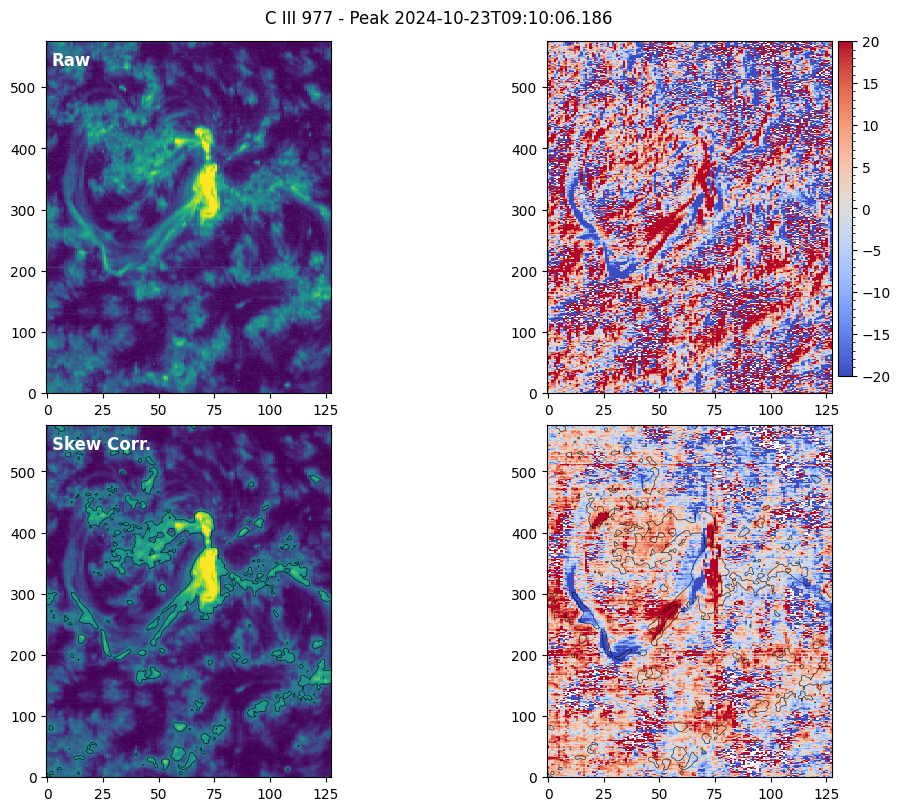

In [18]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(10,8), layout="constrained")

ax1.imshow(raw_CIII_int,
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(raw_CIII_int, 0.5),
                               vmax=np.nanpercentile(raw_CIII_int, 99.5),
                               stretch=AsinhStretch(0.05)))

im2 = ax2.imshow(raw_CIII_vel,
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

ax3.imshow(skew_CIII_int,
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(skew_CIII_int, 0.5),
                               vmax=np.nanpercentile(skew_CIII_int, 99.5),
                               stretch=AsinhStretch(0.05)))

im4 = ax4.imshow(skew_CIII_vel,
           origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

ax1.text(0.02, 0.97, "Raw", transform=ax1.transAxes, ha="left", va="top", weight="bold", fontsize=12,
        color="white")

ax3.text(0.02, 0.97, "Skew Corr.", transform=ax3.transAxes, ha="left", va="top", weight="bold", fontsize=12,
        color="white")

clb, clb_ax = plot_colorbar(im2, ax2, bbox_to_anchor=[1.02, 0.05, 0.05, 0.95])

fig.suptitle(spice_CIII_header['EXTNAME'] + " " +spice_CIII_header['DATE-BEG'], fontsize=12)

# for ax_ in (ax1,ax2):
#     ax_.axhline(330, color="grey", alpha=0.6, ls="--")
#     ax_.axhline(350, color="grey", alpha=0.6, ls="--")

for ax_ in (ax3,ax4):
    ax_.contour(skew_CIII_int, [np.nanpercentile(skew_CIII_int, 90)], linewidths=0.5, alpha=0.8, colors="black")



In [21]:
if not load_data:
    raw_NeVIII_int = raw_results_NeVIII['linefits']['Ne VIII 770 - Peak']['Ne VIII 770']['amplitudes'].data[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax'],0,0].T
    raw_NeVIII_vel = detrend_dopp(raw_results_NeVIII['linefits']['Ne VIII 770 - Peak']['Ne VIII 770']['centers'])[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax']].T
    raw_NeVIII_vel_err = raw_results_NeVIII['linefits']['Ne VIII 770 - Peak']['Ne VIII 770']['centers'].uncertainty.array[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax'],0,0].T


    skew_NeVIII_int = best_correction_results_NeVIII['linefits']['Ne VIII 770 - Peak']['Ne VIII 770']['amplitudes'].data[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax'],0,0].T
    skew_NeVIII_vel = detrend_dopp(best_correction_results_NeVIII['linefits']['Ne VIII 770 - Peak']['Ne VIII 770']['centers'])[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax']].T
    skew_NeVIII_vel_err = best_correction_results_NeVIII['linefits']['Ne VIII 770 - Peak']['Ne VIII 770']['centers'].uncertainty.array[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax'],0,0].T
else:
    raw_NeVIII_linefits = raw_results_NeVIII['linefits'].item()
    raw_results_NeVIII_ymin = raw_results_NeVIII['ymin'].item()
    raw_results_NeVIII_ymax = raw_results_NeVIII['ymax'].item()

    raw_NeVIII_int = raw_NeVIII_linefits[0][0]['amplitudes'].data[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax,0,0].T
    raw_NeVIII_vel = detrend_dopp(raw_NeVIII_linefits[0][0]['centers'])[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax].T
    raw_NeVIII_vel_err = raw_NeVIII_linefits[0][0]['centers'].uncertainty.array[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax,0,0].T

    skew_NeVIII_linefits = best_correction_results_NeVIII['linefits'].item()

    skew_NeVIII_int = skew_NeVIII_linefits[0][0]['amplitudes'].data[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax,0,0].T
    skew_NeVIII_vel = detrend_dopp(skew_NeVIII_linefits[0][0]['centers'])[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax].T
    skew_NeVIII_vel_err = skew_NeVIII_linefits[0][0]['centers'].uncertainty.array[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax,0,0].T  
    

raw_NeVIII_vel_mask = np.abs(raw_NeVIII_vel_err) > 0.05
raw_NeVIII_vel[raw_NeVIII_vel_mask] = np.nan
raw_NeVIII_vel = raw_NeVIII_vel - np.nanmedian(raw_NeVIII_vel[:150, :60]) 
raw_NeVIII_vel = raw_NeVIII_vel/770.428*const.c.to_value(u.km/u.s) # from Xia et al. (2004)

skew_NeVIII_vel_mask = np.abs(skew_NeVIII_vel_err) > 0.05
skew_NeVIII_vel[skew_NeVIII_vel_mask] = np.nan
skew_NeVIII_vel = skew_NeVIII_vel - np.nanmedian(skew_NeVIII_vel[:150, :60])
skew_NeVIII_vel = skew_NeVIII_vel/770.428*const.c.to_value(u.km/u.s)

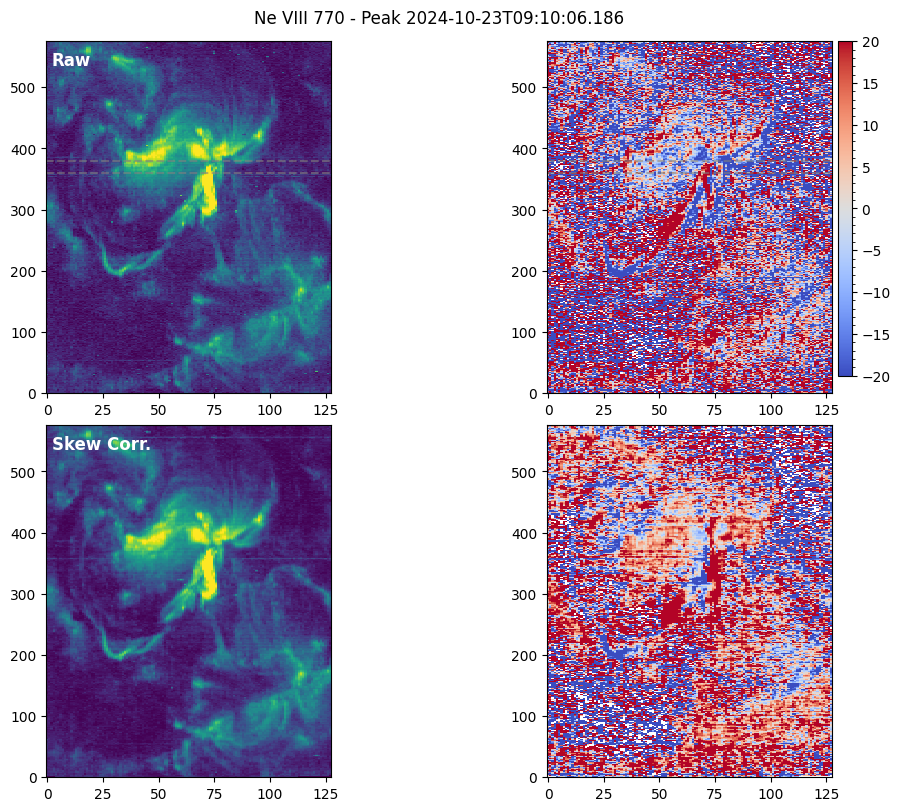

In [22]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(10,8), layout="constrained")

ax1.imshow(raw_NeVIII_int,
           origin="lower", aspect=spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(raw_NeVIII_int, 0.5),
                               vmax=np.nanpercentile(raw_NeVIII_int, 99.5),
                               stretch=AsinhStretch(0.1)))

im2 = ax2.imshow(raw_NeVIII_vel,
           origin="lower", aspect=spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

ax3.imshow(skew_NeVIII_int,
           origin="lower", aspect=spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(skew_NeVIII_int, 0.5),
                               vmax=np.nanpercentile(skew_NeVIII_int, 99.5),
                               stretch=AsinhStretch(0.1)))

im4 = ax4.imshow(skew_NeVIII_vel,
           origin="lower", aspect=spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

ax1.text(0.02, 0.97, "Raw", transform=ax1.transAxes, ha="left", va="top", weight="bold", fontsize=12,
        color="white")

ax3.text(0.02, 0.97, "Skew Corr.", transform=ax3.transAxes, ha="left", va="top", weight="bold", fontsize=12,
        color="white")

clb, clb_ax = plot_colorbar(im2, ax2, bbox_to_anchor=[1.02, 0.05, 0.05, 0.95])

fig.suptitle(spice_NeVIII_header['EXTNAME'] + " " +spice_NeVIII_header['DATE-BEG'], fontsize=12)


for ax_ in (ax1,ax2):
    ax_.axhline(360, color="grey", alpha=0.6, ls="--")
    ax_.axhline(380, color="grey", alpha=0.6, ls="--")